<a href="https://colab.research.google.com/github/chiranmainayak/data-cleaning-and-visualization/blob/main/TASK_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

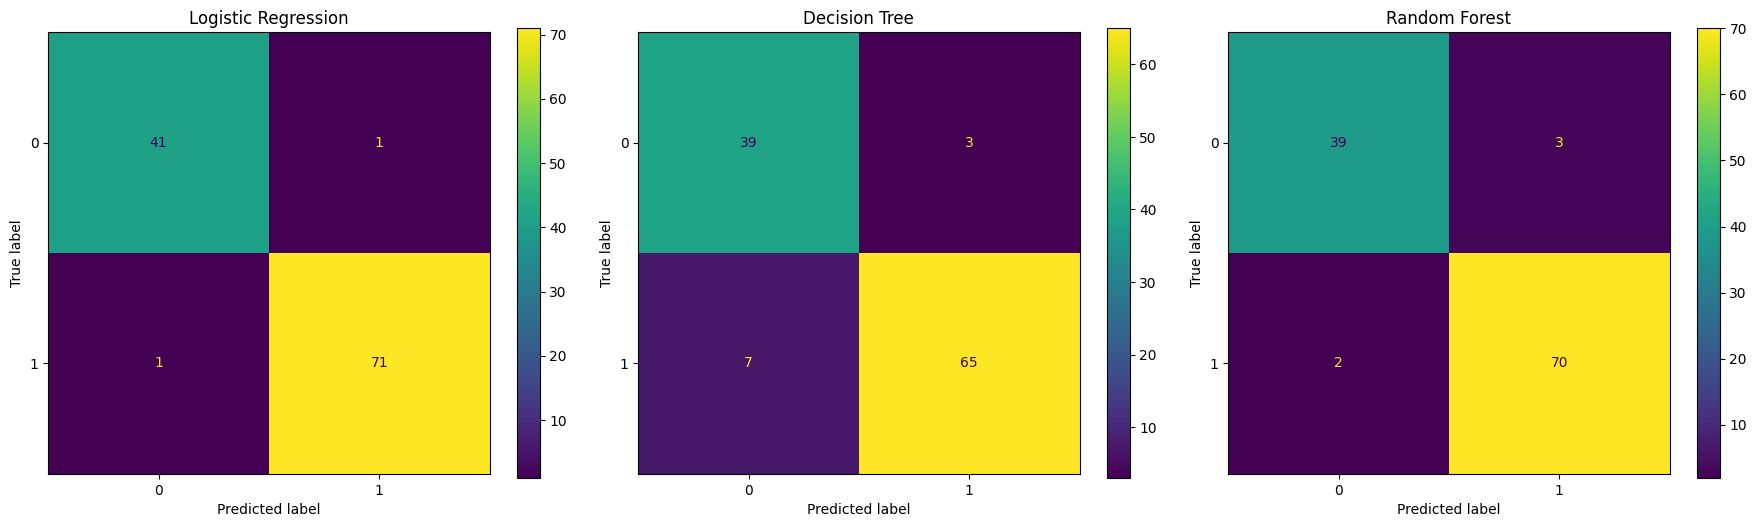

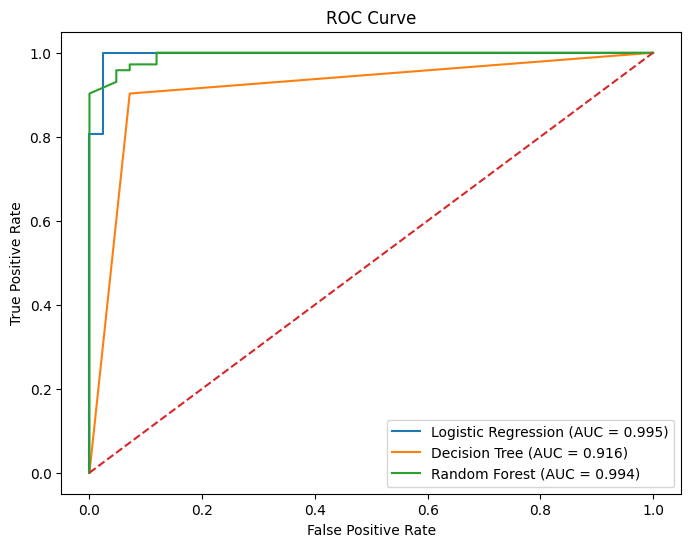

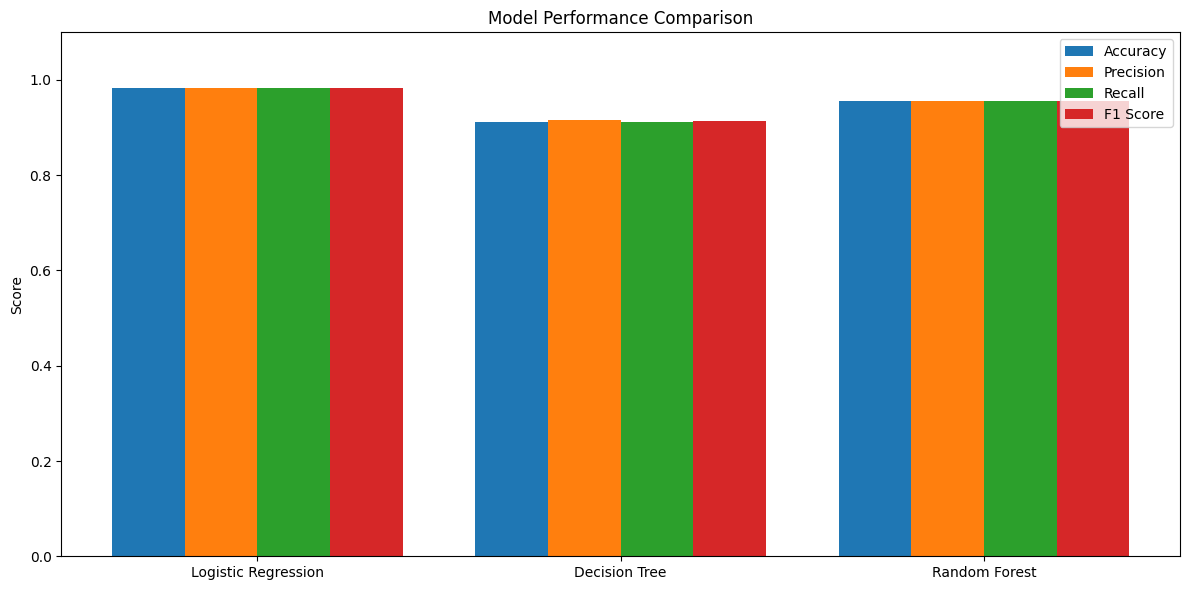

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # Added this line to include the target column

print(df.head())
print(df.shape)
print(df.info())

df = df.drop_duplicates()

target_column = "target"

df = df.dropna(subset=[target_column])

X = df.drop(columns=[target_column])
y = df[target_column]

categorical_columns = X.select_dtypes(include=["object", "category"]).columns
numerical_columns = X.select_dtypes(include=np.number).columns

for column in categorical_columns:
    X[column] = X[column].fillna(X[column].mode()[0])

for column in numerical_columns:
    X[column] = X[column].fillna(X[column].median())

for column in categorical_columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column].astype(str))

if y.dtype == "object" or str(y.dtype) == "category":
    target_encoder = LabelEncoder()
    y = target_encoder.fit_transform(y.astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
decision_tree_pred = decision_tree_model.predict(X_test)
random_forest_pred = random_forest_model.predict(X_test)

accuracy1 = accuracy_score(y_test, logistic_pred)
precision1 = precision_score(y_test, logistic_pred, average="weighted", zero_division=0)
recall1 = recall_score(y_test, logistic_pred, average="weighted", zero_division=0)
f1score1 = f1_score(y_test, logistic_pred, average="weighted", zero_division=0)

accuracy2 = accuracy_score(y_test, decision_tree_pred)
precision2 = precision_score(y_test, decision_tree_pred, average="weighted", zero_division=0)
recall2 = recall_score(y_test, decision_tree_pred, average="weighted", zero_division=0)
f1score2 = f1_score(y_test, decision_tree_pred, average="weighted", zero_division=0)

accuracy3 = accuracy_score(y_test, random_forest_pred)
precision3 = precision_score(y_test, random_forest_pred, average="weighted", zero_division=0)
recall3 = recall_score(y_test, random_forest_pred, average="weighted", zero_division=0)
f1score3 = f1_score(y_test, random_forest_pred, average="weighted", zero_division=0)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy1,
        accuracy2,
        accuracy3
    ],
    "Precision": [
        precision1,
        precision2,
        precision3
    ],
    "Recall": [
        recall1,
        recall2,
        recall3
    ],
    "F1 Score": [
        f1score1,
        f1score2,
        f1score3
    ]
})

print("\nMODEL COMPARISON")
print(results)

best_model = results.loc[results["F1 Score"].idxmax(), "Model"]

print("\nBEST MODEL:", best_model)

print("\nLOGISTIC REGRESSION")
print(classification_report(y_test, logistic_pred, zero_division=0))

print("\nDECISION TREE")
print(classification_report(y_test, decision_tree_pred, zero_division=0))

print("\nRANDOM FOREST")
print(classification_report(y_test, random_forest_pred, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, logistic_pred)
).plot(ax=axes[0])

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, decision_tree_pred)
).plot(ax=axes[1])

axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, random_forest_pred)
).plot(ax=axes[2])

axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

models = [
    ("Logistic Regression", logistic_model, X_test_scaled),
    ("Decision Tree", decision_tree_model, X_test),
    ("Random Forest", random_forest_model, X_test)
]

plt.figure(figsize=(8, 6))

for name, model, test_data in models:

    if len(np.unique(y)) == 2:

        probabilities = model.predict_proba(test_data)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, probabilities)

        auc_score = roc_auc_score(y_test, probabilities)

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC = {auc_score:.3f})"
        )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(results["Model"]))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        results[metric],
        width,
        label=metric
    )

plt.xticks(x, results["Model"])
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()